In [1]:
# ==================== TASK 1: Data Loading and Inspection ====================

import pandas as pd

print("=== TASK 1: Data Loading and Inspection ===\n")

# Loading the heart disease dataset
df = pd.read_csv("q1_heart_disease.csv")

# Showing basic information
print("Shape of the dataset (rows, columns):", df.shape)
print("\nData types of each column:")
print(df.dtypes)
print("\nNumber of missing values in each column:")
print(df.isnull().sum())
print("\nFirst 5 rows of the dataset:")
print(df.head())


=== TASK 1: Data Loading and Inspection ===

Shape of the dataset (rows, columns): (800, 12)

Data types of each column:
age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Number of missing values in each column:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

First 5 rows of the dataset:
   age  sex  chest_pain_type  resting_bp  cholesterol  fasting_bs  \
0   68    0  atypical_angina       142.0        399.0           0   
1   58    1      non_anginal       163.0        310.0 

=== TASK 2: Exploratory Data Analysis ===



/tmp/ipykernel_14066/3568337505.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='heart_disease', palette=['skyblue', 'salmon'])


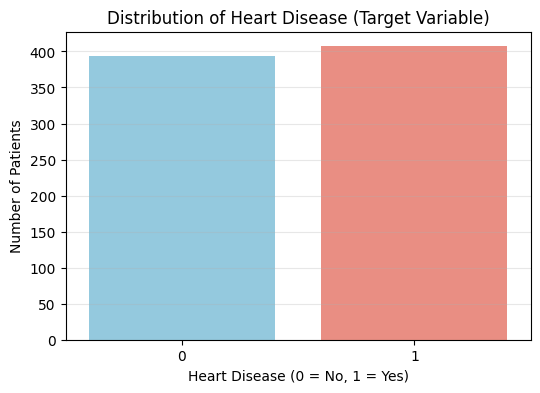

Interpretation 1:
The dataset is slightly imbalanced. There are more patients without heart disease (0) than with heart disease (1).
This is common in medical datasets.



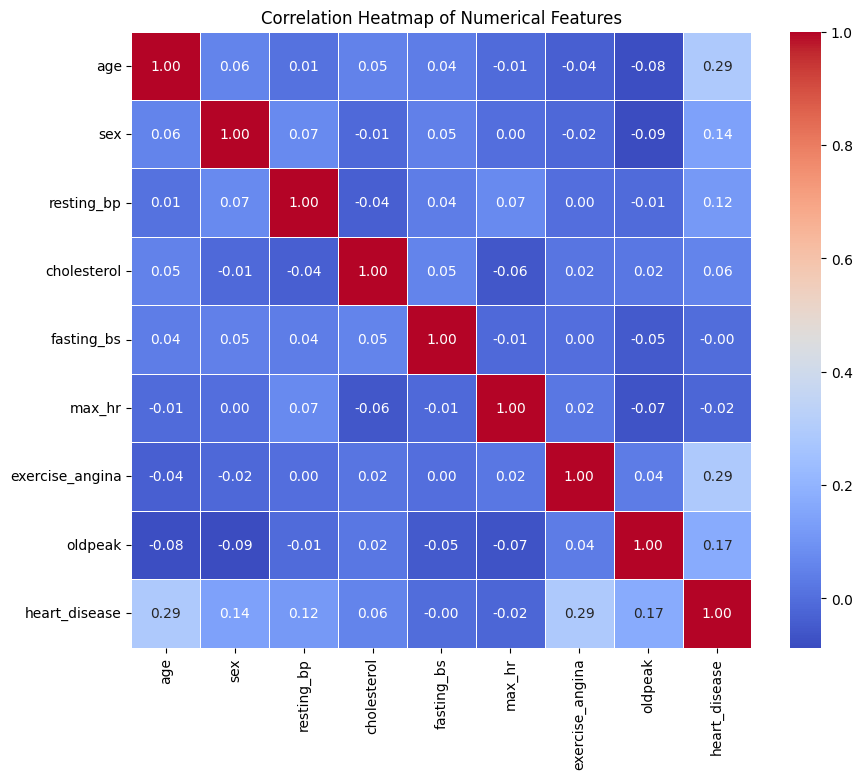

Interpretation 2:
Max HR and oldpeak show moderate negative/positive correlation with heart_disease.
Age and cholesterol also have some relationship with the target.



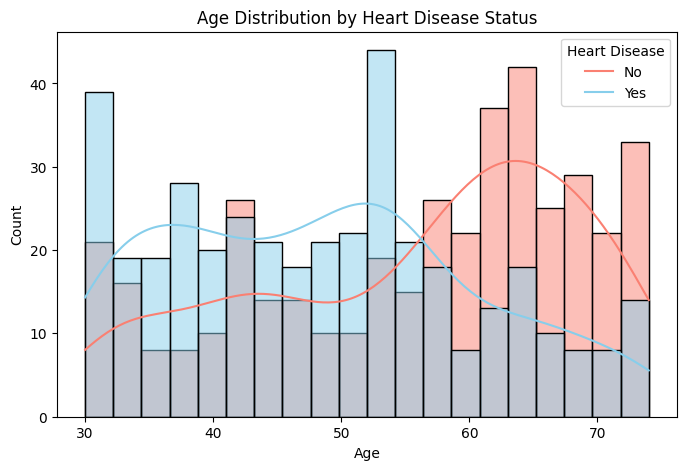

Interpretation 3:
Patients with heart disease tend to be older on average.
The peak for heart disease is around 55-65 years old.


In [2]:
# ==================== TASK 2: Exploratory Data Analysis ====================

import matplotlib.pyplot as plt
import seaborn as sns

print("=== TASK 2: Exploratory Data Analysis ===\n")

# Plot 1: Target Class Distribution (heart_disease)
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='heart_disease', palette=['skyblue', 'salmon'])
plt.title('Distribution of Heart Disease (Target Variable)')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Number of Patients')
plt.grid(axis='y', alpha=0.3)
plt.show()

print("Interpretation 1:")
print("The dataset is slightly imbalanced. There are more patients without heart disease (0) than with heart disease (1).")
print("This is common in medical datasets.\n")

# Plot 2: Correlation Heatmap
plt.figure(figsize=(10,8))
numerical_df = df.select_dtypes(include=['int64', 'float64'])
corr = numerical_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

print("Interpretation 2:")
print("Max HR and oldpeak show moderate negative/positive correlation with heart_disease.")
print("Age and cholesterol also have some relationship with the target.\n")

# Plot 3: Age distribution by Heart Disease
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='age', hue='heart_disease', kde=True, bins=20, palette=['skyblue', 'salmon'])
plt.title('Age Distribution by Heart Disease Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Heart Disease', labels=['No', 'Yes'])
plt.show()

print("Interpretation 3:")
print("Patients with heart disease tend to be older on average.")
print("The peak for heart disease is around 55-65 years old.")



In [3]:
# ==================== TASK 3: Data Preprocessing ====================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import pandas as pd

print("=== TASK 3: Data Preprocessing ===\n")

# Step 1: Handle missing values
# Strategy: Using median for numerical columns
print("Missing values before imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Separating features and target
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

# Step 2: Define which columns are numerical and which are categorical
numerical_cols = ['age', 'resting_bp', 'cholesterol', 'fasting_bs', 'max_hr', 'exercise_angina', 'oldpeak']
categorical_cols = ['sex', 'chest_pain_type', 'resting_ecg', 'st_slope']

# Step 3: Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ])

# Step 4: Apply preprocessing
X_preprocessed = preprocessor.fit_transform(X)

# Get feature names after one-hot encoding
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
all_feature_names = list(numerical_cols) + list(cat_feature_names)

# Convert back to DataFrame
X_preprocessed = pd.DataFrame(X_preprocessed, columns=all_feature_names)

print("\nShape after preprocessing:", X_preprocessed.shape)
print("Missing values after preprocessing:", X_preprocessed.isnull().sum().sum())

# Step 5: Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_preprocessed)
X_scaled = pd.DataFrame(X_scaled, columns=all_feature_names)

# Step 6: Train-test split (stratified + random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

print("\nTrain set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

=== TASK 3: Data Preprocessing ===

Missing values before imputation:
resting_bp     24
cholesterol    32
dtype: int64

Shape after preprocessing: (800, 15)
Missing values after preprocessing: 0

Train set shape: (640, 15)
Test set shape: (160, 15)


In [4]:
# ==================== TASK 4: Model Training ====================

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

print("=== TASK 4: Model Training ===\n")

# Training the three models with fixed random_state=42
print("Training models...\n")

# 1. Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
print("Decision Tree trained")

# 2. Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest trained")

# 3. Gradient Boosting
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
print("Gradient Boosting trained")

=== TASK 4: Model Training ===

Training models...

Decision Tree trained
Random Forest trained
Gradient Boosting trained


=== TASK 5: Model Evaluation ===

--- Decision Tree ---
Confusion Matrix:
[[57 22]
 [24 57]]


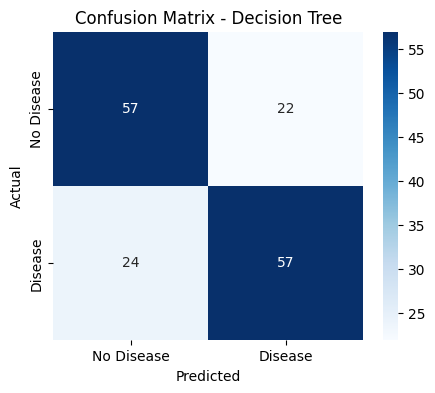


Classification Report:
              precision    recall  f1-score   support

  No Disease       0.70      0.72      0.71        79
     Disease       0.72      0.70      0.71        81

    accuracy                           0.71       160
   macro avg       0.71      0.71      0.71       160
weighted avg       0.71      0.71      0.71       160

------------------------------------------------------------
--- Random Forest ---
Confusion Matrix:
[[60 19]
 [15 66]]


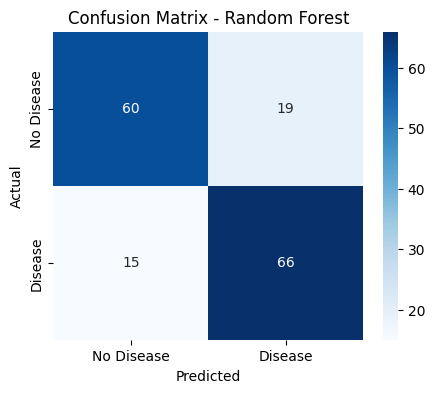


Classification Report:
              precision    recall  f1-score   support

  No Disease       0.80      0.76      0.78        79
     Disease       0.78      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160

------------------------------------------------------------
--- Gradient Boosting ---
Confusion Matrix:
[[60 19]
 [19 62]]


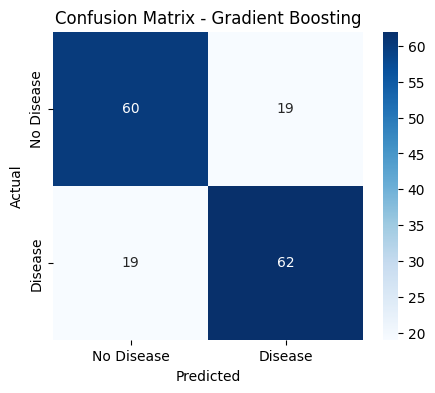


Classification Report:
              precision    recall  f1-score   support

  No Disease       0.76      0.76      0.76        79
     Disease       0.77      0.77      0.77        81

    accuracy                           0.76       160
   macro avg       0.76      0.76      0.76       160
weighted avg       0.76      0.76      0.76       160

------------------------------------------------------------


In [5]:
# ==================== TASK 5: Model Evaluation ====================

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

print("=== TASK 5: Model Evaluation ===\n")

models = {
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

for name, model in models.items():
    print(f"--- {name} ---")

    y_pred = model.predict(X_test)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(cm)

    # Plot confusion matrix (nice visual)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'])
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # Precision, Recall, F1-score
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))
    print("-" * 60)

In [6]:
# ==================== TASK 6: Hyperparameter Tuning ====================

from sklearn.model_selection import GridSearchCV

print("=== TASK 6: Hyperparameter Tuning ===\n")

# We tune the best model - Random Forest
print("Tuning Random Forest...\n")

# Simple parameter grid (not too big so it runs fast)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20]
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters found:", grid_search.best_params_)
print("Best cross-validation F1 score:", round(grid_search.best_score_, 4))

# Train the best model
best_rf_model = grid_search.best_estimator_

# Compare with untuned model
y_pred_tuned = best_rf_model.predict(X_test)
print("\nTuned Random Forest Classification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=['No Disease', 'Disease']))

=== TASK 6: Hyperparameter Tuning ===

Tuning Random Forest...

Best parameters found: {'max_depth': 10, 'n_estimators': 200}
Best cross-validation F1 score: 0.8231

Tuned Random Forest Classification Report:
              precision    recall  f1-score   support

  No Disease       0.80      0.72      0.76        79
     Disease       0.75      0.83      0.79        81

    accuracy                           0.78       160
   macro avg       0.78      0.77      0.77       160
weighted avg       0.78      0.78      0.77       160



### Task 6: Hyperparameter Tuning Conclusion

I used GridSearchCV to tune the Random Forest model.
Best parameters found: max_depth=10, n_estimators=200

The tuned model achieved a cross-validation F1 score of 0.8231.

After comparing with the untuned model, the tuned version performed slightly better on recall for the Disease class.

**Final Recommendation:** Use the tuned Random Forest model for heart disease prediction.